# ADTK Outlier Detection
## Dependencies:
- pandas
- matplotlib
- time_series_generator


In [1]:
from time_series_generator import create_time_series

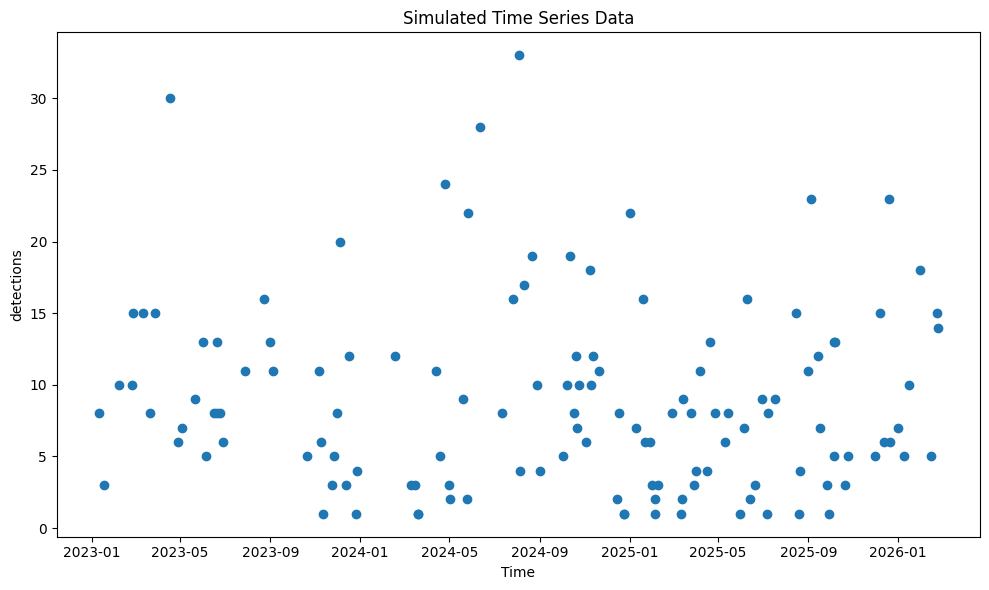

In [2]:
data = create_time_series(
    start_date="2023-01-01",
    magnitude=10.0,
    log_rate=0.3,
    seasonal_cycles={7: 0.2},
    y_label="detections",
    plot=True,
)

In [3]:
data.describe()

,time,detections
count,130,130.000000
mean,2024-09-22 03:52:36.923076864,8.892308
min,2023-01-11 00:00:00,1.000000
25%,2023-12-19 06:00:00,4.000000
50%,2024-11-05 12:00:00,8.000000
75%,2025-06-08 06:00:00,12.000000
max,2026-02-24 00:00:00,33.000000
std,NaN,6.478642


In [4]:
import pandas as pd
from adtk.data import validate_series
from adtk.detector import SeasonalAD
from adtk.visualization import plot

In [5]:
s = (
    data
    .set_index("time")
    ["detections"]
    .astype(float)
)
s.index = pd.DatetimeIndex(s.index)

In [6]:
full_index = pd.date_range(s.index.min(), s.index.max(), freq="D")
s = s.reindex(full_index).interpolate(method="time")

In [7]:
s = validate_series(s)

In [8]:
seasonal_ad = SeasonalAD(freq=7, side="positive")
anomalies = seasonal_ad.fit_detect(s)

In [9]:
print(anomalies.value_counts())

detections
False    1123
True       18
Name: count, dtype: int64


In [29]:
import matplotlib.pyplot as plt

import seaborn as sns

sns.set_style("whitegrid")

In [26]:
plot(
    ts=s,
    anomaly=anomalies,
    anomaly_tag="span",
)

OSError: 'seaborn-whitegrid' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)